<a href="https://colab.research.google.com/github/oscmoral/Programacion-para-analitica-descriptiva-y-predictiva/blob/main/Pr%C3%A1ctica_Ejercicios_sobre_Clases_No_Balanceadas%2C_Data_Leakage_(Pipeline)_y_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Ejercicios sobre Clases No Balanceadas, Data Leakage (Pipeline) y SVM


SVM

Nombre: Oscar Morales Martinez

Materia: Programación para analítica descriptiva y predictiva

Carrera: Maestría en Inteligencia Artificial y Analítica de Datos

## Instrucciones

La presente tarea tiene como objetivo aplicar técnicas de aprendizaje automático para el tratamiento de clases no balanceadas utilizando un problema de clasificación real.

Para el desarrollo de la actividad deberán utilizar el conjunto de datos:

**compustat.csv**

Consideraciones importantes:

* El conjunto de datos contiene 21 atributos.

* El primer atributo corresponde a un índice, por lo que deberá ser ignorado durante el análisis y entrenamiento.

* El último atributo corresponde a la etiqueta de clase.

* Los atributos restantes deberán utilizarse como variables predictoras.

La solución deberá desarrollarse en un cuaderno de Google Colab o Jupyter Notebook almacenado en GitHub. La entrega consistirá en compartir la liga pública del notebook para su revisión.

La tarea deberá contener las siguientes secciones:

1. Análisis Exploratorio de Datos (AED) - **Para esta actividad revisa el Notebook que està en Teams en la Sesión 27 y que se llama DataLeakage_ClassImbalance.ipynb**

Realizar:

* Un diagrama de barras mostrando la distribución de las clases.

* Diagramas de densidad KDE para los atributos 5 y 13.

* Un análisis breve sobre el nivel de desbalance presente en el conjunto de datos.

2. Modelo Base

Entrenar un modelo baseline utilizando:

```python
Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale'
    ))
])
```

Este modelo deberá entrenarse sin aplicar métodos de tratamiento de desbalance y servirá como referencia para comparar los resultados posteriores.

3. Tratamiento de Clases No Balanceadas

Aplicar y comparar los siguientes métodos:

* SMOTEENN

* One-Sided Selection

Para cada método:

* Mostrar la nueva distribución de clases después del balanceo.

* Entrenar nuevamente el modelo SVM utilizando los datos balanceados.

4. Entrenamiento y Evaluación del Modelo

* Utilizar validación cruzada estratificada de 5 particiones.

* Implementar el flujo de trabajo utilizando Pipeline para evitar data leakage.

* Incorporar escalado de datos dentro del Pipeline.

* Utilizar SVM con kernel RBF.

5. Evaluación de Resultados

Reportar y analizar al menos las siguientes métricas:

* Accuracy

* Precision

* Recall

* F1-score

* Matriz de confusión

Además:

* Comparar los resultados del modelo baseline contra los modelos balanceados.

* Generar una gráfica comparativa de métricas.

* Analizar si Accuracy es suficiente para evaluar el problema.

6. Discusión y Conclusiones

Discutir:

* El impacto del desbalance sobre el desempeño del modelo.

* Las diferencias observadas entre SMOTEENN y One-Sided Selection.

* Qué método produjo los mejores resultados y por qué.

Se espera que el notebook incluya explicaciones claras del procedimiento realizado, interpretación crítica de resultados y conclusiones técnicas fundamentadas.

## 1. Análisis Exploratorio de Datos (AED)

En esta sección se revisa la estructura general del dataset `compustat.csv`, la distribución de la variable objetivo y el comportamiento de algunos atributos mediante gráficas KDE.

El objetivo principal es identificar si existe desbalance entre clases y observar si algunos atributos presentan diferencias entre la clase mayoritaria y minoritaria.

Paso 1. Acceso a google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Paso 2. Cargar dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

path = "/content/drive/MyDrive/ClassFiles/compustat.csv"

df = pd.read_csv(path)

print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (13657, 22)


,idx,at0,at1,at2,at3,at4,at5,at6,at7,at8,...,at11,at12,at13,at14,at15,at16,at17,at18,at19,label
0,0,0.076753,0.066548,0.132170,4.257882,0.771988,0.669344,0.076278,2.898450,6.081867,...,2.052378,0.372113,0.322636,0.250182,1.153351,0.451476,0.590680,0.512143,0.076278,0
1,1,0.097633,0.087736,0.162879,4.141787,0.781934,0.702665,0.082633,2.947445,6.272092,...,1.968984,0.371728,0.334043,0.231646,1.112813,0.409376,0.593143,0.533012,0.056273,0
2,2,0.025683,0.022020,0.152882,3.140505,0.698522,0.598883,0.097905,2.971928,6.508112,...,1.374306,0.305678,0.262075,0.220100,1.166375,0.487141,0.476098,0.408186,0.050251,0
3,3,0.011354,0.008987,0.165670,2.927575,0.699374,0.553558,0.107831,2.955952,6.588417,...,1.173407,0.280317,0.221873,0.245524,1.263416,0.487903,0.460482,0.364474,0.047244,0
4,4,0.001675,0.001212,0.155509,3.120983,0.689971,0.499122,0.098458,2.896668,6.607998,...,1.069792,0.236504,0.171086,0.271291,1.382369,0.464594,0.468896,0.339197,0.042986,0


Paso 3. Definir índice, predictores y etiqueta

In [10]:
index_col = df.columns[0]
target_col = df.columns[-1]

X = df.iloc[:, 1:-1]
y = df.iloc[:, -1]

print("Columna ignorada (índice):", index_col)
print("Variable objetivo:", target_col)
print("Variables predictoras:", X.shape[1])

print("\nDistribución de clases:")
print(y.value_counts())

Columna ignorada (índice): idx
Variable objetivo: label
Variables predictoras: 20

Distribución de clases:
label
0    13137
1      520
Name: count, dtype: int64


Paso 4. Gráfica de barras con porcentajes

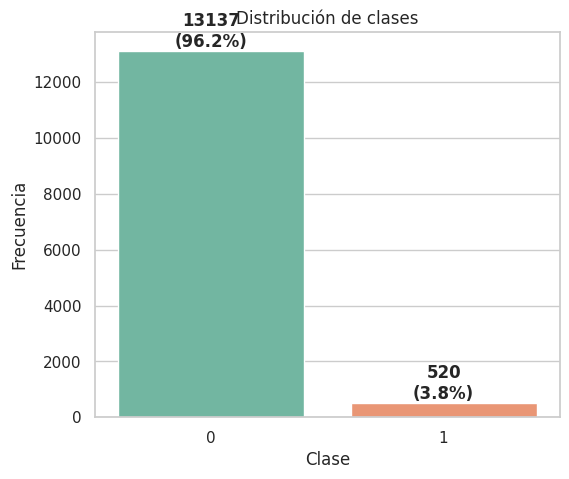

In [11]:
class_counts = y.value_counts().sort_index()
class_percentages = y.value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    x=class_counts.index.astype(str),
    y=class_counts.values,
    hue=class_counts.index.astype(str),
    palette="Set2",
    legend=False
)

for i, value in enumerate(class_counts.values):
    percentage = class_percentages.iloc[i]
    ax.text(
        i,
        value,
        f"{value}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

Paso 4. Nivel de desbalance

In [12]:
majority_class = class_counts.max()
minority_class = class_counts.min()

imbalance_ratio = majority_class / minority_class

print("Clase mayoritaria:", majority_class)
print("Clase minoritaria:", minority_class)
print("Razón de desbalance:", round(imbalance_ratio, 2), "a 1")

Clase mayoritaria: 13137
Clase minoritaria: 520
Razón de desbalance: 25.26 a 1


### Interpretación del desbalance

La gráfica de barras muestra la cantidad de observaciones por clase.  
Si una clase concentra muchas más observaciones que la otra, existe un problema de clases no balanceadas.

Este desbalance puede afectar el entrenamiento del modelo, ya que el clasificador puede aprender a favorecer la clase mayoritaria. Por esta razón, la métrica `accuracy` puede resultar engañosa y es necesario analizar también `precision`, `recall` y `F1-score`.

Paso 5. KDE para atributo 5

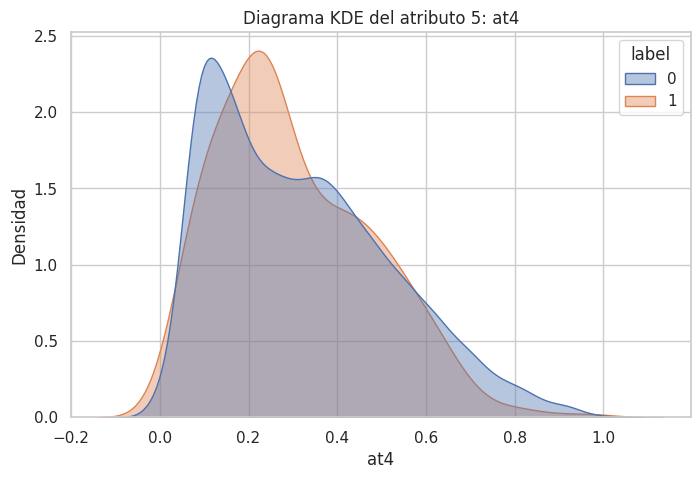

In [13]:
attribute_5 = X.columns[4]

plot_df = X.copy()
plot_df[target_col] = y

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=plot_df,
    x=attribute_5,
    hue=target_col,
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title(f"Diagrama KDE del atributo 5: {attribute_5}")
plt.xlabel(attribute_5)
plt.ylabel("Densidad")
plt.show()

Paso 6. KDE para atributo 13

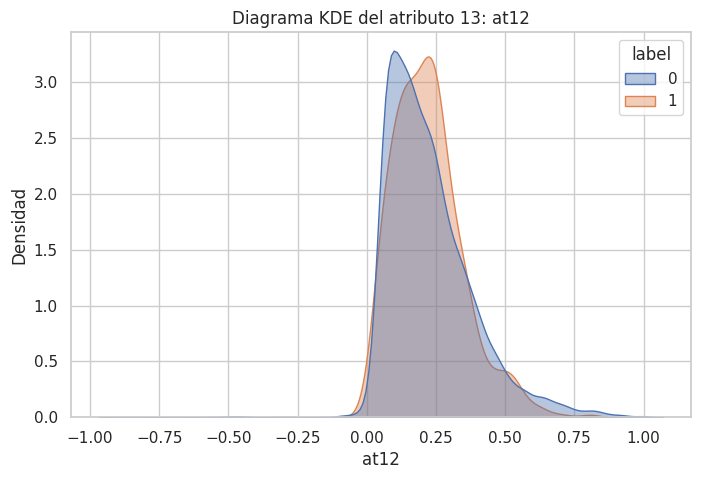

In [14]:
attribute_13 = X.columns[12]

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=plot_df,
    x=attribute_13,
    hue=target_col,
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title(f"Diagrama KDE del atributo 13: {attribute_13}")
plt.xlabel(attribute_13)
plt.ylabel("Densidad")
plt.show()

### Interpretación de los diagramas KDE

Los diagramas KDE permiten comparar la distribución de cada atributo según la clase.

Si las curvas de ambas clases se superponen mucho, significa que ese atributo por sí solo no separa claramente las clases.  
Si las curvas muestran diferencias visibles, el atributo podría aportar información útil para el modelo.

En problemas con clases no balanceadas, este tipo de análisis ayuda a observar si la clase minoritaria tiene patrones distintos o si queda mezclada con la clase mayoritaria.

## 2. Modelo base

Paso 1. Importar modelos y métricas

In [15]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from imblearn.pipeline import Pipeline

Paso 2. Pipeline baseline

In [16]:
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

Paso 3. Validación cruzada estratificada

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_baseline = cross_val_predict(
    baseline_pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

Paso 4. Métricas baseline

In [18]:
def evaluate_model(y_true, y_pred, model_name):
    results = {
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }

    print(model_name)
    print(classification_report(y_true, y_pred, zero_division=0))

    return results

baseline_results = evaluate_model(y, y_pred_baseline, "Baseline")

Baseline
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     13137
           1       1.00      0.01      0.02       520

    accuracy                           0.96     13657
   macro avg       0.98      0.50      0.50     13657
weighted avg       0.96      0.96      0.94     13657



Paso 5. Matriz de confusión baseline

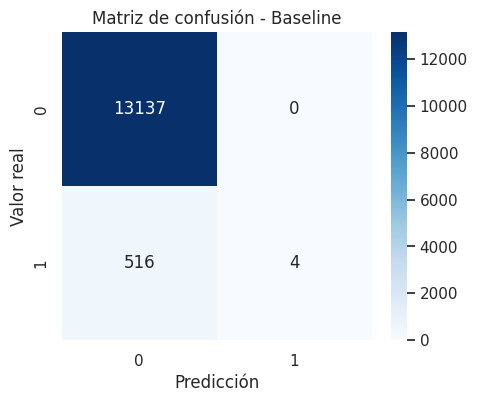

In [19]:
cm = confusion_matrix(y, y_pred_baseline)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Baseline")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## 3. Tratamiento de Clases No Balanceadas

Paso 1. SMOTEENN

In [20]:
from imblearn.combine import SMOTEENN

smoteenn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smoteenn", SMOTEENN(random_state=42)),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

Paso 2. Mostrar nueva distribución

In [21]:
X_scaled = StandardScaler().fit_transform(X)

smoteenn = SMOTEENN(random_state=42)
X_smoteenn, y_smoteenn = smoteenn.fit_resample(X_scaled, y)

print("Distribución después de SMOTEENN:")
print(pd.Series(y_smoteenn).value_counts())

Distribución después de SMOTEENN:
label
1    13109
0    11826
Name: count, dtype: int64


Paso 3. Entrenar y evaluar con CV

In [22]:
y_pred_smoteenn = cross_val_predict(
    smoteenn_pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

smoteenn_results = evaluate_model(y, y_pred_smoteenn, "SMOTEENN")

SMOTEENN
              precision    recall  f1-score   support

           0       0.99      0.81      0.89     13137
           1       0.14      0.80      0.24       520

    accuracy                           0.81     13657
   macro avg       0.57      0.81      0.57     13657
weighted avg       0.96      0.81      0.87     13657



Paso 4. Matriz de confusión - SMOTEENN

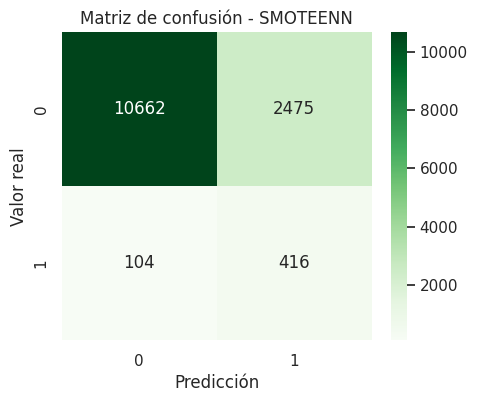

In [23]:
cm = confusion_matrix(y, y_pred_smoteenn)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusión - SMOTEENN")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

Paso 5. One-Sided Selection

In [24]:
from imblearn.under_sampling import OneSidedSelection

oss_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("oss", OneSidedSelection(random_state=42, n_jobs=-1)),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

Paso 6. Mostrar nueva distribución

In [25]:
oss = OneSidedSelection(random_state=42, n_jobs=-1)
X_oss, y_oss = oss.fit_resample(X_scaled, y)

print("Distribución después de One-Sided Selection:")
print(pd.Series(y_oss).value_counts())

Distribución después de One-Sided Selection:
label
0    12853
1      520
Name: count, dtype: int64


Paso 7. Entrenar y evaluar con CV

In [26]:
y_pred_oss = cross_val_predict(
    oss_pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1
)

oss_results = evaluate_model(y, y_pred_oss, "One-Sided Selection")

One-Sided Selection
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     13137
           1       0.75      0.01      0.02       520

    accuracy                           0.96     13657
   macro avg       0.86      0.51      0.50     13657
weighted avg       0.95      0.96      0.94     13657



Paso 8. Matriz de confusión - One-Sided Selection

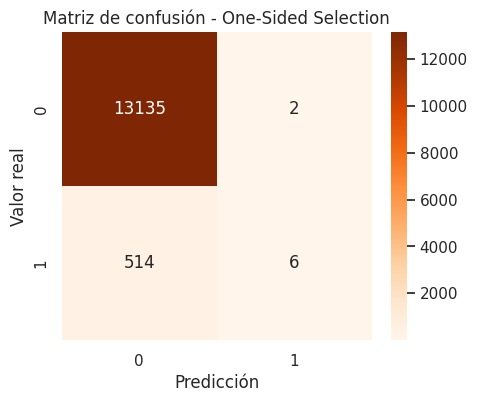

In [27]:
cm = confusion_matrix(y, y_pred_oss)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Matriz de confusión - One-Sided Selection")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## 5. Evaluación de Resultados

In [28]:
results_df = pd.DataFrame([
    baseline_results,
    smoteenn_results,
    oss_results
])

results_df

,Modelo,Accuracy,Precision,Recall,F1-score
0,Baseline,0.962217,1.000000,0.007692,0.015267
1,SMOTEENN,0.811159,0.143895,0.800000,0.243917
2,One-Sided Selection,0.962217,0.750000,0.011538,0.022727


Paso 1. Gráfica comparativa

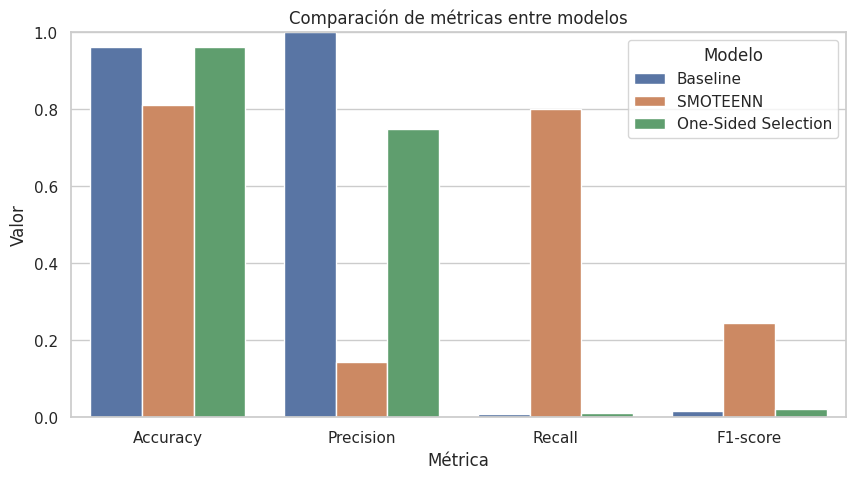

In [29]:
results_melted = results_df.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=results_melted,
    x="Métrica",
    y="Valor",
    hue="Modelo"
)

plt.title("Comparación de métricas entre modelos")
plt.ylim(0, 1)
plt.legend(title="Modelo")
plt.show()

## 6. Discusión y Conclusiones

## Discusión de resultados

El modelo baseline se entrenó sin aplicar técnicas de balanceo. Debido al desbalance de clases, es posible que obtenga una accuracy alta, pero esto no necesariamente significa que clasifique correctamente la clase minoritaria.

SMOTEENN combina sobremuestreo y limpieza de datos. Este método puede mejorar el recall de la clase minoritaria porque genera ejemplos sintéticos y elimina observaciones ambiguas.

One-Sided Selection es una técnica de submuestreo que reduce ejemplos de la clase mayoritaria. Su ventaja es que conserva observaciones importantes, pero puede no equilibrar tanto como SMOTEENN.

Accuracy no es suficiente para evaluar este problema, ya que con clases desbalanceadas un modelo puede predecir mayormente la clase dominante y aun así obtener buen accuracy. Por eso es más importante analizar recall, precision y F1-score.

## Conclusiones

El desbalance de clases afecta el desempeño del modelo porque puede provocar que el clasificador favorezca la clase mayoritaria.

Al comparar los modelos, se debe prestar especial atención al recall y F1-score de la clase minoritaria, ya que estas métricas reflejan mejor la capacidad del modelo para detectar casos de la clase menos frecuente.

SMOTEENN tiende a mejorar la detección de la clase minoritaria al generar nuevos ejemplos y limpiar datos difíciles. One-Sided Selection reduce la clase mayoritaria, pero puede tener un efecto más conservador.

El mejor método será aquel que logre un equilibrio adecuado entre precision, recall y F1-score, no necesariamente el que tenga mayor accuracy.